# NFL 4th Down Decision Analysis
## Formation & Personnel Analysis

This notebook analyzes the offensive formations, personnel groupings, and defensive alignments used on 4th down go-for-it attempts between 2016 and 2025. We examine which formations and personnel packages convert most efficiently, how defensive box counts affect outcomes, and which coaches favor which formations.

---

### Setup & Data Load
Load the processed dataset and filter to go-for-it plays.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

fourth_downs = pd.read_parquet(os.path.join(processed_path, "fourth_downs.parquet"))
go_for_it = fourth_downs[fourth_downs['decision'] == 'go'].copy()
go_for_it['converted'] = go_for_it['fourth_down_converted'].astype(int)

print(f"Go-for-it plays: {len(go_for_it)}")
print(f"Columns available: {go_for_it.columns.tolist()}")

Go-for-it plays: 7058
Columns available: ['play_id', 'game_id', 'season', 'week', 'posteam', 'defteam', 'home_team', 'away_team', 'home_coach', 'away_coach', 'posteam_type', 'down', 'ydstogo', 'yardline_100', 'score_differential', 'game_seconds_remaining', 'qtr', 'goal_to_go', 'play_type', 'fourth_down_converted', 'fourth_down_failed', 'epa', 'wp', 'wpa', 'field_goal_result', 'punt_attempt', 'field_goal_attempt', 'offense_formation', 'offense_personnel', 'defenders_in_box', 'defense_personnel', 'defense_man_zone_type', 'defense_coverage_type', 'coach', 'decision', 'converted']


All formation and personnel columns confirmed in the dataset. We have 7,058 go-for-it plays with formation, personnel, and defensive alignment data available for analysis.

---

### Clean Personnel Data
The raw `offense_personnel` column contains full roster descriptions like "1 C, 2 G, 1 QB, 1 RB, 2 T, 1 TE, 3 WR". We simplify this into standard NFL personnel packages based on the number of RBs, TEs, and WRs on the field.

In [2]:
import re

def parse_personnel(personnel_str):
    if pd.isna(personnel_str):
        return None
    rb = int(re.search(r'(\d+) RB', personnel_str).group(1)) if re.search(r'(\d+) RB', personnel_str) else 0
    te = int(re.search(r'(\d+) TE', personnel_str).group(1)) if re.search(r'(\d+) TE', personnel_str) else 0
    wr = int(re.search(r'(\d+) WR', personnel_str).group(1)) if re.search(r'(\d+) WR', personnel_str) else 0
    return f"{rb}{te} ({rb}RB/{te}TE/{wr}WR)"

go_for_it['personnel_package'] = go_for_it['offense_personnel'].apply(parse_personnel)

print(go_for_it['personnel_package'].value_counts().head(10))
print(f"\nMissing: {go_for_it['personnel_package'].isna().sum()}")

personnel_package
11 (1RB/1TE/3WR)    4318
12 (1RB/2TE/2WR)     805
13 (1RB/3TE/1WR)     322
12 (1RB/2TE/1WR)     268
22 (2RB/2TE/1WR)     191
21 (2RB/1TE/2WR)     138
10 (1RB/0TE/4WR)     116
21 (2RB/1TE/1WR)     104
11 (1RB/1TE/2WR)      98
22 (2RB/2TE/0WR)      73
Name: count, dtype: int64

Missing: 28


Personnel packages successfully cleaned into standard NFL groupings. The distribution is heavily concentrated in a few packages:

- **11 personnel (1RB/1TE/3WR) — 4,318 plays (62%)** — by far the most common, the modern NFL's base offensive package
- **12 personnel (1RB/2TE/2WR) — 805 plays (11%)** — second most common, adds a TE for blocking or receiving
- **13 personnel (1RB/3TE/1WR) — 322 plays (5%)** — heavy formation, typically used in short yardage
- **22 personnel (2RB/2TE/1WR) — 191 plays (3%)** — power formation, two backs and two tight ends

Only 28 missing values — clean enough to proceed directly to analysis.

---

### Formation Conversion Rates
Which offensive formations convert most efficiently on 4th down go-for-it attempts?

offense_formation  attempts  conversion_rate   avg_epa
     UNDER CENTER       764         0.700262  0.486239
            JUMBO       201         0.696517  0.483417
           I_FORM       352         0.659091  0.301488
       SINGLEBACK       721         0.649098  0.221190
           PISTOL       111         0.594595  0.110363
          WILDCAT        31         0.548387 -0.192450
          SHOTGUN      4070         0.469287 -0.036838
            EMPTY       499         0.464930 -0.018369


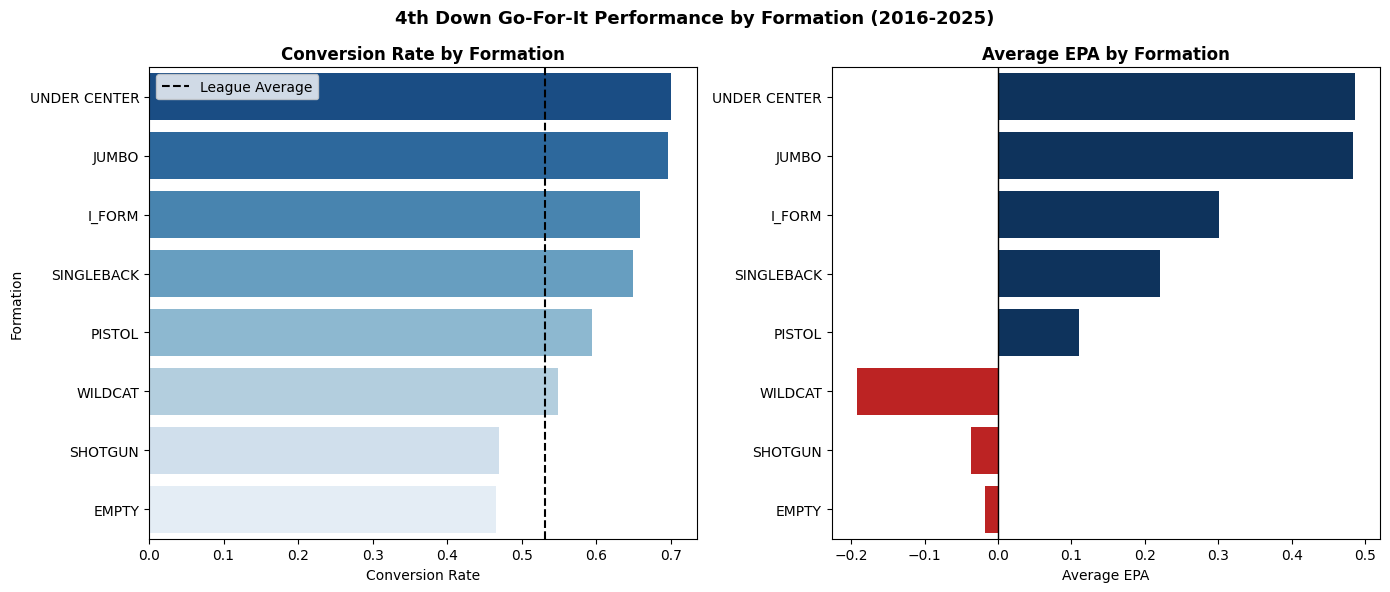

In [4]:
# Formation conversion rates
formation_conv = go_for_it.dropna(subset=['offense_formation']).groupby('offense_formation').agg(
    attempts=('converted', 'count'),
    conversion_rate=('converted', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index().sort_values('conversion_rate', ascending=False)

print(formation_conv.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Conversion rate
sns.barplot(data=formation_conv, x='conversion_rate', y='offense_formation',
            hue='offense_formation',
            palette='Blues_r', legend=False, ax=axes[0])
axes[0].axvline(x=go_for_it['converted'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Average')
axes[0].set_title('Conversion Rate by Formation', fontweight='bold')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Formation')
axes[0].legend()

# EPA
colors = ['#013369' if x > 0 else '#D50A0A' for x in formation_conv['avg_epa']]
sns.barplot(data=formation_conv, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(formation_conv['offense_formation'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Average EPA by Formation', fontweight='bold')
axes[1].set_xlabel('Average EPA')
axes[1].set_ylabel('')

plt.suptitle('4th Down Go-For-It Performance by Formation (2016-2025)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "formation_conversion_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Formation Conversion Rate and EPA](../outputs/figures/formation_conversion_epa.png)

The formation data reveals a striking and counterintuitive finding — the formations teams use most on 4th down are actually the least effective.

**Conversion rate by formation:**
| Formation | Attempts | Conversion Rate | Avg EPA |
|---|---|---|---|
| Under Center | 764 | 70% | +0.49 |
| Jumbo | 201 | 70% | +0.48 |
| I-Form | 352 | 66% | +0.30 |
| Singleback | 721 | 65% | +0.22 |
| Pistol | 111 | 59% | +0.11 |
| Wildcat | 31 | 55% | -0.19 |
| Shotgun | 4,070 | 47% | -0.04 |
| Empty | 499 | 46% | -0.02 |

**The key finding:**
- **Shotgun is used on 62% of go-for-it plays** yet converts at only 47% — below the league average of 53%
- **Under Center converts at 70%** — 23 percentage points higher than Shotgun — yet is used on only 11% of plays
- **Jumbo and I-Form** are the next most effective formations, both converting above 65%, yet combined they account for only 8% of go-for-it attempts

This directly mirrors the pass/run finding from notebook 05 — teams are systematically favoring modern spread formations (Shotgun, Empty) despite traditional formations (Under Center, Jumbo, I-Form) converting at dramatically higher rates. The NFL's shift toward pass-heavy offense may be costing teams on 4th down specifically.

---

### Personnel Package Conversion Rates
Does the personnel grouping on the field matter as much as the formation?

personnel_package  attempts  conversion_rate   avg_epa
 12 (1RB/2TE/0WR)        60         0.750000  1.168480
 21 (2RB/1TE/1WR)       104         0.692308  0.805276
 22 (2RB/2TE/1WR)       191         0.638743  0.191567
 12 (1RB/2TE/1WR)       268         0.626866  0.163865
 22 (2RB/2TE/0WR)        73         0.616438  0.185685
 11 (1RB/1TE/2WR)        98         0.612245  0.011285
 13 (1RB/3TE/1WR)       322         0.599379  0.098726
 21 (2RB/1TE/2WR)       138         0.586957  0.181064
 12 (1RB/2TE/2WR)       805         0.578882  0.138606
 13 (1RB/3TE/0WR)        52         0.519231 -0.570655
 11 (1RB/1TE/3WR)      4318         0.499768  0.043223
 01 (0RB/1TE/4WR)        51         0.450980 -0.124858
 10 (1RB/0TE/4WR)       116         0.439655 -0.143925


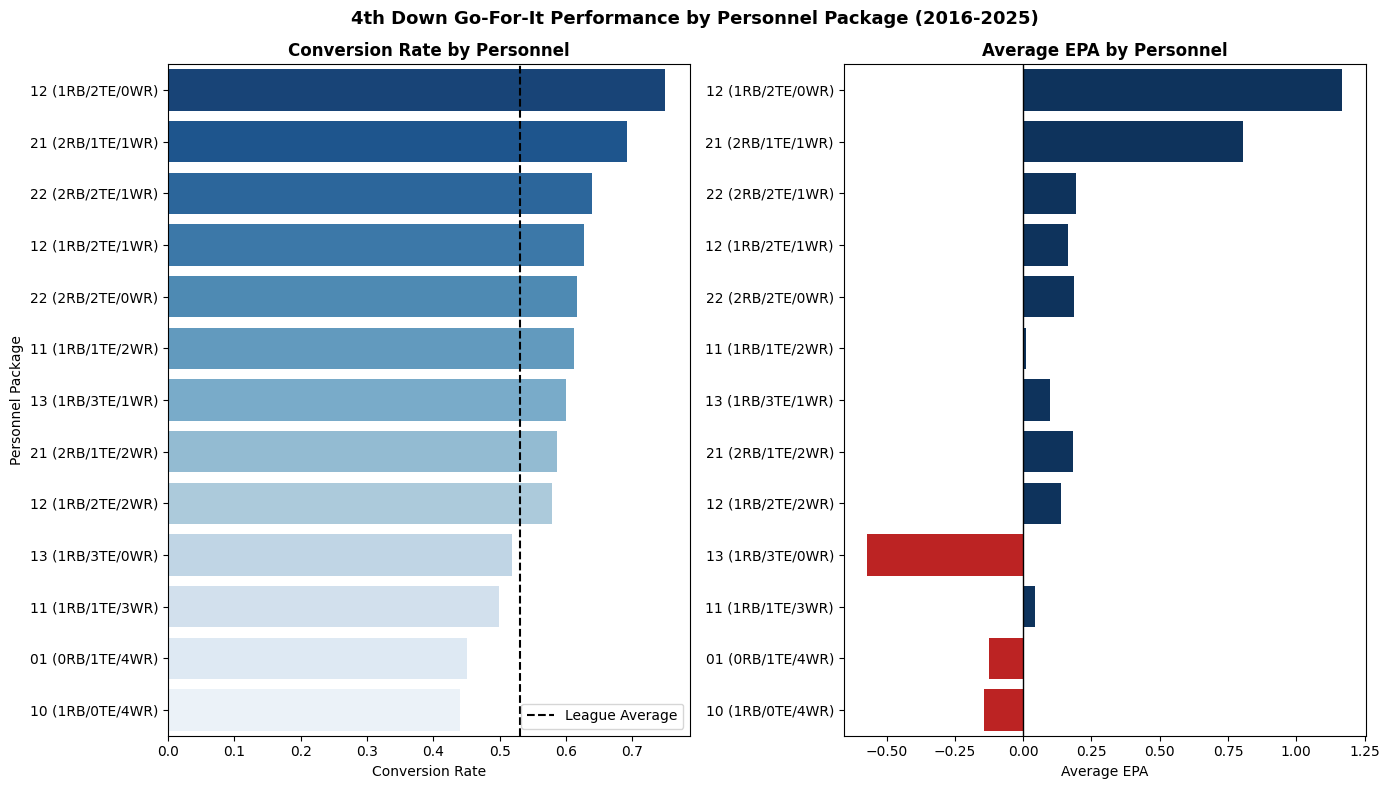

In [5]:
# Personnel package conversion rates (minimum 50 attempts)
personnel_conv = go_for_it.dropna(subset=['personnel_package']).groupby('personnel_package').agg(
    attempts=('converted', 'count'),
    conversion_rate=('converted', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index()

personnel_conv = personnel_conv[personnel_conv['attempts'] >= 50].sort_values('conversion_rate', ascending=False)

print(personnel_conv.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Conversion rate
sns.barplot(data=personnel_conv, x='conversion_rate', y='personnel_package',
            hue='personnel_package', palette='Blues_r', legend=False, ax=axes[0])
axes[0].axvline(x=go_for_it['converted'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Average')
axes[0].set_title('Conversion Rate by Personnel', fontweight='bold')
axes[0].set_xlabel('Conversion Rate')
axes[0].set_ylabel('Personnel Package')
axes[0].legend()

# EPA
colors = ['#013369' if x > 0 else '#D50A0A' for x in personnel_conv['avg_epa']]
sns.barplot(data=personnel_conv, x='avg_epa', y='personnel_package',
            hue='personnel_package',
            palette=dict(zip(personnel_conv['personnel_package'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].set_title('Average EPA by Personnel', fontweight='bold')
axes[1].set_xlabel('Average EPA')
axes[1].set_ylabel('')

plt.suptitle('4th Down Go-For-It Performance by Personnel Package (2016-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "personnel_conversion_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Personnel Package Conversion Rate and EPA](../outputs/figures/personnel_conversion_epa.png)

The personnel data reinforces and deepens the formation finding — heavy, run-oriented packages dramatically outperform spread packages on 4th down.

**Key findings by personnel:**
| Personnel | Attempts | Conversion Rate | Avg EPA |
|---|---|---|---|
| 12 (1RB/2TE/0WR) | 60 | 75% | +1.17 |
| 21 (2RB/1TE/1WR) | 104 | 69% | +0.81 |
| 22 (2RB/2TE/1WR) | 191 | 64% | +0.19 |
| 12 (1RB/2TE/1WR) | 268 | 63% | +0.16 |
| 11 (1RB/1TE/3WR) | 4,318 | 50% | +0.04 |
| 10 (1RB/0TE/4WR) | 116 | 44% | -0.14 |

**The most important finding:**
- **12 personnel with no wide receivers (75% conversion, +1.17 EPA)** — the most effective package in the dataset by both metrics, yet used on only 60 plays total
- **21 personnel (69% conversion, +0.81 EPA)** — second most effective, also heavily underutilized at 104 plays
- **11 personnel (50% conversion, +0.04 EPA)** — the most common package at 4,318 plays yet converts below league average
- **10 personnel with 4 WRs (44% conversion, -0.14 EPA)** — the worst performing spread package, used on 116 plays

The pattern is consistent and clear: **the more receivers on the field, the worse the conversion rate**. Teams going to empty backfield or 4-wide sets on 4th down are actively hurting their chances. The data strongly suggests that heavy personnel packages with multiple tight ends and running backs are the optimal choice for 4th down conversion attempts — yet the NFL continues to trend in the opposite direction.

---

### Defenders in the Box
How does the number of defenders in the box affect conversion rates on go-for-it attempts?

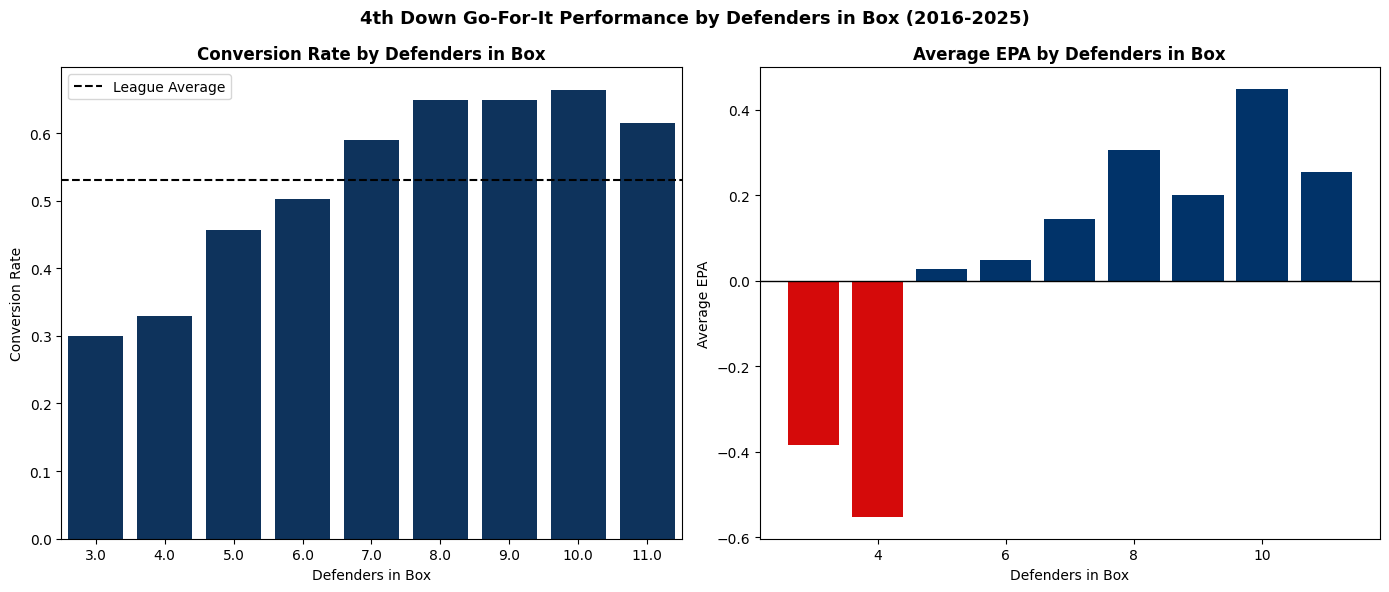

 defenders_in_box  attempts  conversion_rate   avg_epa
              3.0        80         0.300000 -0.385112
              4.0       471         0.329087 -0.553597
              5.0      1025         0.456585  0.026473
              6.0      2235         0.502908  0.047491
              7.0      1509         0.589132  0.145171
              8.0       950         0.649474  0.306639
              9.0       307         0.648208  0.200670
             10.0       125         0.664000  0.448740
             11.0        70         0.614286  0.254684


In [6]:
# Defenders in box conversion rate
box_conv = go_for_it.dropna(subset=['defenders_in_box']).groupby('defenders_in_box').agg(
    attempts=('converted', 'count'),
    conversion_rate=('converted', 'mean'),
    avg_epa=('epa', 'mean')
).reset_index()

# Filter to common box counts
box_conv = box_conv[box_conv['attempts'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Conversion rate
sns.barplot(data=box_conv, x='defenders_in_box', y='conversion_rate',
            color='#013369', ax=axes[0])
axes[0].axhline(y=go_for_it['converted'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Average')
axes[0].set_title('Conversion Rate by Defenders in Box', fontweight='bold')
axes[0].set_xlabel('Defenders in Box')
axes[0].set_ylabel('Conversion Rate')
axes[0].legend()

# EPA
colors = ['#013369' if x > 0 else '#D50A0A' for x in box_conv['avg_epa']]
axes[1].bar(box_conv['defenders_in_box'], box_conv['avg_epa'], color=colors)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Average EPA by Defenders in Box', fontweight='bold')
axes[1].set_xlabel('Defenders in Box')
axes[1].set_ylabel('Average EPA')

plt.suptitle('4th Down Go-For-It Performance by Defenders in Box (2016-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "defenders_in_box.png"), dpi=150, bbox_inches='tight')
plt.show()

print(box_conv.to_string(index=False))

![Defenders in Box](../outputs/figures/defenders_in_box.png)

The defenders in box data reveals a surprising and counterintuitive finding — teams actually convert better against more defenders in the box.

**Conversion rate by box count:**
- **3-4 defenders (30-33%)** — the lowest conversion rates in the dataset, well below league average
- **5-6 defenders (46-50%)** — below league average, light boxes are not as favorable as expected
- **7+ defenders (59-66%)** — above league average, heavy boxes correlate with higher conversion rates

**Why does this happen?**
This seems counterintuitive at first — more defenders should mean harder to convert. But the explanation lies in **play selection and situation**. When defenses load the box with 8+ defenders they are telegraphing run defense, which forces offenses into passing situations where they have a numbers advantage in the secondary. Additionally, teams tend to go for it against heavy boxes in short yardage situations where conversion rates are already high regardless of defensive alignment.

The EPA chart tells a consistent story — negative EPA against light boxes (3-4 defenders) and strongly positive EPA against heavy boxes (8-11 defenders), suggesting teams are better equipped to execute go-for-it plays when the defense is showing its hand with a loaded box.

---

### Summary
This notebook reveals that formation and personnel selection on 4th down go-for-it attempts has a dramatic impact on conversion rates:

1. **Shotgun is used 62% of the time but converts at only 47%** — below league average
2. **Under Center converts at 70%** — 23 percentage points higher than Shotgun yet used on only 11% of plays
3. **Heavy personnel packages (12, 21, 22) dramatically outperform spread packages** — 12 personnel with no WRs converts at 75% vs 44% for 4-wide sets
4. **More receivers on the field correlates directly with lower conversion rates** — the NFL's pass-heavy trend is working against teams on 4th down
5. **Heavy boxes actually correlate with higher conversion rates** — teams perform better against loaded boxes than light ones, suggesting defensive alignment is less predictive than offensive formation choice